# Optimisation sous multiples contraintes

Ce sujet est proposé par Ludovic Goudenège.
Vous pouvez adresser vos questions ou remarques à ludovic.goudenege@polytechnique.edu

Le but de ce projet est de trouver le minimum d'une fonctionnelle, qui n'est ni strictement convexe, ni minorée sur $\mathbb{R}^N$, grâce à deux contraintes inégalités qui assurent l'existence et l'unicité du minimum.
Deux approches sont possibles pour résoudre le problème :


* En premier lieu, en imposant une contrainte active du problème et en oubliant l'autre, on va diminuer le nombre d'inconnues pour mettre en place des algorithmes classiques de descente sans contrainte. Si, à l'issue de cette optimisation, la deuxième contrainte n'est pas violée, on a trouvé un minimum. Sinon cela signifie que les deux contraintes sont actives.

* Dans un second temps, on mettra en place un algorithme de descente de type Uzawa, avec prise en compte des contraintes, en prenant garde au fait que le problème ne satisfait pas les hypothèses nécessaires à la convergence de cet algorithme.

## 1) Modélisation et mise en place du problème
### 1-1) Modèle continu

On considère une barre métallique fine (considérée comme un fil de dimension 1) de longueur $L=1$, représentée par le domaine spatial $[0,1]$.

Cette barre est soumise à un **apport thermique uniforme**, par exemple un chauffage dû à la circulation d'un courant électrique.

On suppose que le **flux de chaleur aux extrémités** peut être contrôlé et est imposé par des contraintes de type Neumann homogène.

La chaleur va naturellement se répartir dans tout le fil métallique, mais pour des raisons de contrôle ou de sécurité, on souhaite imposer que la température aux deux extrêmités ne dépasse pas une certaine valeur, notées respectivement $g\in\mathbb{R}$ et $d\in\mathbb{R}$ au point gauche $0$ et au point droit $1$.

Si on note $\Theta:[0,1] \to \mathbb{R}$ la température dans la barre et qu'on attend le régime stationnaire, on peut montrer que ce régime stationnaire est caractérisé comme un minimiseur d'une **énergie quadratique** du type
$$
\mathcal{E}(\Theta) = \frac12 \int_0^1 |\Theta'(x)|^2 dx - c \int_0^1 \Theta(x) dx,
$$

où le premier terme pénalise les grandes variations de températures (i.e. les forts gradients) et le second représente l'apport thermique uniforme de valeur $c\in\mathbb{R}_+$.

On impose ensuite les **contraintes sur les bords** :
$$
\Theta(0) \le g \quad\text{ et }\quad \Theta(1) \le d.
$$

### 1-2) Discrétisation du problème
On discrétise ce domaine $[0,1]$ en $N+2$ points régulièrement espacés.

On note $\theta_i$ la **température** au point $x_i := i/(N+1) \in (0,1)$ pour $i\in\{0,1, 2, \dots, N, N+1\}$, c'est-à-dire $\theta_i = \Theta(x_i)$ ; et $\theta$ le vecteur $(\theta_1, \dots, \theta_N) \in \mathbb{R}^N$ qui ne contient pas les données extrêmales.

Au niveau discret, l'énergie $\mathcal{E}$ s'apparennte à la fonctionnelle :
$$
J_N(\theta) = \frac12 \sum_{i=1}^{N-1} (\theta_{i+1} - \theta_i)^2 - C \sum_{i=1}^N \theta_i.
$$

Le terme
$$
\frac12 \sum_{i=1}^{N-1} (\theta_{i+1} - \theta_i)^2
$$
représente le premier terme de la fonctionnelle $\mathcal{E}$ pénalisant les **gradients de température**.
Plus ce terme est petit, plus la température est lisse.

Le terme linéaire
$$
C \sum_{i=1}^N \theta_i
$$
modélise le second terme de la fonctionnelle $\mathcal{E}$ modélisant l'**apport thermique uniforme** de valeur $c\in\mathbb{R}_+$.
Attention $c\neq C$, car la constante $C$ pourrait dépendre de $N$ pour rester consistant vis-à-vis de l'énergie continue $\mathcal{E}$.
Plus la température $\theta$ est élevée, plus ce terme diminue l'énergie, donc il favorise les températures élevées.

En écriture matricielle, la fonctionnelle $J_N$ s’écrit :
$$
J_N(\theta) = \frac12 \langle A \theta, \theta \rangle - C \langle b, \theta \rangle,
$$
où $A \in \mathcal{M}_N(\mathbb{R})$ est la matrice du **Laplacien discret 1D** tenant compte des **conditions de Neumann** traduisant la condition de flux imposé aux extrémités, et $b = \mathbf{1} \in \mathbb{R}^N$ est le vecteur dont toutes les composantes valent 1.

La contrainte de Neumann homogène s'écrit $\theta'(0)=0=\theta'(1)$, ce qui en éliminant $\theta_0$ et $\theta_{N+1}$ des équations discrètes permet de se ramener aux contraintes aux deux bords
$$
\theta_1 \le g\quad\text{ et }\quad \theta_N \le d.
$$

On va donc chercher à minimiser la fonctionnelle quadratique
$J: \mathbb R^N \rightarrow \mathbb R$ avec :
\begin{equation}
 A=
 \begin{pmatrix}
 1&-1&0&0&0&\ldots &0\\
 -1&2&-1&0& \ddots&\ddots&\vdots\\
 0&-1&2&-1&0&\ddots&\vdots\\
 0&\ddots&\ddots&\ddots&\ddots&\ddots&0\\
 \vdots&\ddots&0&-1&2&-1 &0\\
\vdots&\ddots&\ddots&0&-1&2&-1\\
0&\ldots&0& 0&0& -1&1
\end{pmatrix} \in \mathcal M _{N}(\mathbb R)
\end{equation}
et $b=(1,\dots, 1)\in \mathbb{R}^N$.

On aurait pu considérer un vecteur $b$ quelconque pour modéliser un apport thermique non uniforme, mais pour simplifier ce problème, on fixe $b=\mathbb{1}$ le vecteur ne contenant que des $1$.

### 1-3) Questions de mathématiques

* 1) Trouver deux valeurs $\alpha$ et $\beta$ telles que pour toute fonction $\Theta$ de classe $\mathcal{C}^2$ avec $\theta_i := \Theta(\frac{i}{N+1})$ pour tout $i\in\{0,1, 2, \dots, N, N+1\}$, on ait
$
\lim_{N\rightarrow+\infty} \left(N^\alpha \frac12 \sum_{i=1}^{N-1} (\theta_{i+1} - \theta_i)^2 - c N^\beta \sum_{i=1}^N \theta_i \right)= \mathcal{E}(\Theta).$
On rappelle qu'on peut approcher $\Theta'$ par $\frac{\theta_{i+1}-\theta_{i}}{x_{i+1}-x_i}$.
* 2) Montrer que la matrice $A$ est positive, mais pas définie positive.
* 3) En déduire que la fonctionnelle $J_N$ n'est pas $\alpha$-convexe.
* 4) En posant $\mathbb{1}$ le vecteur ne contenant que des $1$, montrer que pour tout $\theta\in \mathbb{R}^N$, on a $J_N(\theta+\mathbb{1}) < J_N(\theta)$ et donc que la fonctionnelle $J_N$ n'est ni strictement convexe, ni minorée sur $\mathbb{R}^N$.

**REPONSES** 

* 1)
On pose $ h=\frac{1}{N+1} $. Comme
$$
\frac{\theta_{i+1}-\theta_i}{h}\simeq \Theta'(x_i),
 $$
on a
$$
(\theta_{i+1}-\theta_i)^2\simeq h^2|\Theta'(x_i)|^2.
$$
Ainsi
$$
\sum_{i=1}^{N-1}(\theta_{i+1}-\theta_i)^2
\simeq h^2\sum_{i=1}^{N-1}|\Theta'(x_i)|^2
= h\left(h\sum_{i=1}^{N-1}|\Theta'(x_i)|^2\right).
$$
Comme $ h\sim 1/N $, il faut multiplier ce terme par $ N $, donc
$$
\alpha=1.
$$ 

De plus,
$$
h\sum_{i=1}^N \theta_i
\to \int_0^1 \Theta(x)\,dx.
$$
Donc
$$
\sum_{i=1}^N\theta_i \sim N\int_0^1\Theta(x)\,dx.
$$
Il faut donc multiplier cette somme par $1/N$, ce qui donne
$$
\beta=-1.
$$

Finalement,
$$
\boxed{\alpha=1,\qquad \beta=-1.}
$$

* 2)
$$
A=
\begin{pmatrix}
1 & -1 & 0 & \cdots & 0\\
-1 & 2 & -1 & \ddots & \vdots\\
0 & -1 & 2 & \ddots & 0\\
\vdots & \ddots & \ddots & 2 & -1\\
0 & \cdots & 0 & -1 & 1
\end{pmatrix}.
$$

Montrons que $ A $ est positive. Soit
$$
v=(v_1,\ldots,v_N)\in\mathbb R^N.
$$
Alors
$$
v^\top A v
=
v_1(v_1-v_2)
+
\sum_{i=2}^{N-1}v_i(2v_i-v_{i-1}-v_{i+1})
+
v_N(v_N-v_{N-1}).
$$

En réarrangeant les termes, on obtient
$$
v^\top A v
=
\sum_{i=1}^{N-1}(v_{i+1}-v_i)^2.
$$



Ainsi,
$$
v^\top A v
=
\sum_{i=1}^{N-1}(v_{i+1}-v_i)^2
\ge 0.
$$
Donc $ A $ est positive, c'est-à-dire positive semi-définie.

Cependant, $ A $ n'est pas définie positive. En effet, si
$$
\mathbf 1=(1,\ldots,1)\in\mathbb R^N,
$$
alors
$$
A\mathbf 1=0.
$$
Autrement dit, $\mathbf 1$ est un vecteur propre associé à la valeur propre $0$.
De manière équivalente,
$$
\mathbf 1^\top A\mathbf 1
=
\sum_{i=1}^{N-1}(1-1)^2
=
0,
$$
alors que $\mathbf 1\neq 0$.

Donc
$$
A \ge 0,
\qquad
\text{mais}
\qquad
A \not> 0.
$$

* 3)
On a montré que
$$
A\mathbf 1=0,
\qquad
\mathbf 1=(1,\ldots,1)\in\mathbb R^N.
$$
Nous allons en déduire que $ J_N $ n'est pas $\alpha$-convexe.

Soit $ u\in\mathbb R^N $ et soit $ t\in\mathbb R$, $t\neq 0$. Posons
$$
v=u+t\mathbf 1.
$$
Alors, comme $A\mathbf 1=0$, on a
$$
A v
=
A(u+t\mathbf 1)
=
Au+tA\mathbf 1
=
Au.
$$
De plus,
$$
v^\top A v
=
(u+t\mathbf 1)^\top A(u+t\mathbf 1)
=
u^\top A u.
$$

Ainsi, pour
$$
J_N(\theta)
=
\frac12 \theta^\top A\theta
-
C\langle \mathbf 1,\theta\rangle,
$$
on obtient
$$
J_N(u+t\mathbf 1)
=
\frac12 u^\top A u
-
C\langle \mathbf 1,u+t\mathbf 1\rangle.
$$
Donc
$$
J_N(u+t\mathbf 1)
=
J_N(u)-Ct\|\mathbf 1\|^2.
$$
Comme $|\mathbf 1\|^2=N$, cela donne
$$
J_N(u+t\mathbf 1)
=
J_N(u)-CNt.
$$

En particulier, la fonction
$$
t\mapsto J_N(u+t\mathbf 1)
$$
est affine. Donc $ J_N $ n'est pas strictement convexe dans la direction
$ \mathbf 1$.

Montrons maintenant directement que  $J_N $ n'est pas $\alpha$-convexe.
Supposons par contradiction qu'il existe $\alpha>0$ tel que $J_N$ soit
$\alpha$-convexe. Alors, pour tout $\lambda\in(0,1)$,
$$
J_N(\lambda u+(1-\lambda)v)
\le
\lambda J_N(u)+(1-\lambda)J_N(v)
-
\frac{\alpha}{2}\lambda(1-\lambda)\|u-v\|^2.
$$

Or, comme $v=u+t\mathbf 1$, on a
$$
\lambda u+(1-\lambda)v
=
u+(1-\lambda)t\mathbf 1.
$$
Comme $J_N$ est affine dans la direction $\mathbf 1$, on a exactement
$$
J_N(\lambda u+(1-\lambda)v)
=
\lambda J_N(u)+(1-\lambda)J_N(v).
$$

L'inégalité d'$\alpha$-convexité donnerait donc
$$
\lambda J_N(u)+(1-\lambda)J_N(v)
\le
\lambda J_N(u)+(1-\lambda)J_N(v)
-
\frac{\alpha}{2}\lambda(1-\lambda)\|u-v\|^2.
$$
En simplifiant,
$$
0
\le
-
\frac{\alpha}{2}\lambda(1-\lambda)\|u-v\|^2.
$$
Mais $u\neq v$, puisque $t\neq 0$, donc
$$
\|u-v\|^2>0.
$$
Comme $\alpha>0$ et $\lambda(1-\lambda)>0$, le membre de droite est
strictement négatif, ce qui est impossible.

On en conclut que $J_N$ n'est pas $\alpha$-convexe.
* 4)
D'après la question précédente, on sait que
$$
A\mathbb 1=0.
$$
Soit $\theta\in\mathbb R^N$. Alors
$$
J_N(\theta+\mathbb 1)
=
\frac12\langle A(\theta+\mathbb 1),\theta+\mathbb 1\rangle
-
C\langle \mathbb 1,\theta+\mathbb 1\rangle.
$$

Comme $A\mathbb 1=0$, on a
$$
A(\theta+\mathbb 1)=A\theta.
$$
Donc
$$
\langle A(\theta+\mathbb 1),\theta+\mathbb 1\rangle
=
\langle A\theta,\theta+\mathbb 1\rangle
=
\langle A\theta,\theta\rangle
+
\langle A\theta,\mathbb 1\rangle.
$$
Or, comme $A$ est symétrique,
$$
\langle A\theta,\mathbb 1\rangle
=
\langle \theta,A\mathbb 1\rangle
=
0.
$$
Ainsi,
$$
\langle A(\theta+\mathbb 1),\theta+\mathbb 1\rangle
=
\langle A\theta,\theta\rangle.
$$

Pour le terme linéaire, on a
$$
\langle \mathbb 1,\theta+\mathbb 1\rangle
=
\langle \mathbb 1,\theta\rangle
+
\langle \mathbb 1,\mathbb 1\rangle.
$$
Comme
$$
\langle \mathbb 1,\mathbb 1\rangle=N,
$$
on obtient
$$
\langle \mathbb 1,\theta+\mathbb 1\rangle
=
\langle \mathbb 1,\theta\rangle+N.
$$

Par conséquent,
$$
J_N(\theta+\mathbb 1)
=
\frac12\langle A\theta,\theta\rangle
-
C\left(\langle \mathbb 1,\theta\rangle+N\right).
$$
Donc
$$
J_N(\theta+\mathbb 1)
=
J_N(\theta)-CN.
$$
Comme $C>0$ et $N\ge 1$, on a
$$
CN>0.
$$
Ainsi,
$$
\boxed{
J_N(\theta+\mathbb 1)<J_N(\theta).
}
$$

Plus généralement, pour tout $k\in\mathbb N$,
$$
J_N(\theta+k\mathbb 1)
=
J_N(\theta)-CNk.
$$
En faisant tendre $k$ vers $+\infty$, on obtient
$$
J_N(\theta+k\mathbb 1)\longrightarrow -\infty.
$$
Donc $J_N$ n'est pas minorée sur $\mathbb R^N$.

Enfin, la fonction $J_N$ est affine dans la direction $\mathbb 1$. En effet,
pour tout $t\in\mathbb R$,
$$
J_N(\theta+t\mathbb 1)
=
J_N(\theta)-CNt.
$$
Ainsi, sur toute droite de direction $\mathbb 1$, la fonctionnelle est affine.
Elle ne peut donc pas être strictement convexe.

On conclut que
$$
\boxed{
J_N \text{ n'est ni strictement convexe, ni minorée sur } \mathbb R^N.
}
$$

## 2) Approche par activation de contrainte

On pourrait étudier la convergence théorique des algorithmes de descente en faisant varier la constante $C$, et les deux constantes $g$ et $d$.
Mais, pour ce projet, on va se placer dans un cadre simple où $C=1$ ou $2$ et $g\leq d$. Comme le problème est symétrique en $\theta_1$ et $\theta_N$, c'est la constante la plus petite (en l'occurence $g$) qui est susceptible d'être active.

Comme la fonctionnelle n'est ni strictement convexe, ni minorée, a priori aucun théorème ou algorithme du cours ne s'applique. On va toutefois coder les algorithmes d'optimisation sur ce problème spécifique pour explorer les solutions atteignables numériquement.

Comme on l'a annoncé dans l'introduction, la première méthode consiste à forcer une contrainte à être active, et à regarder le problème réduit sans la deuxième contrainte.
In fine, on vérifie simplement si la solution trouvée satisfait la deuxième contrainte.


In [107]:
# Chargement des librairies utilisées.
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

import scipy as sp
from scipy import sparse
from scipy.sparse import linalg, diags

* 5) Définir toutes les variables et toutes les fonctions nécessaires pour construire une fonction python ``fct_J(theta)`` qui s'applique sur un vecteur $\theta$ de $\mathbb{R}^N$. On pourra utiliser la commande sp.sparse.diags pour obtenir une matrice creuse. Vérifier votre implémentation en testant votre matrice $A$ pour $N$ petit.

In [108]:
# REPONSE 5
# Paramètres du problème
N = 5
C = 1.0
g = 0.0
d = 1.0

def matrice_A(N):
    """
    Construit la matrice A du Laplacien discret 1D avec conditions de Neumann.
    A est de taille N x N.
    """
    diag_principale = 2 * np.ones(N)
    diag_principale[0] = 1
    diag_principale[-1] = 1

    diag_inf = -np.ones(N - 1)
    diag_sup = -np.ones(N - 1)

    A = sp.sparse.diags(
        diagonals=[diag_inf, diag_principale, diag_sup],
        offsets=[-1, 0, 1],
        shape=(N, N),
        format="csr"
    )

    return A


# Matrice A et vecteur b = 1
A = matrice_A(N)
b = np.ones(N)


def fct_J(theta):
    """
    Calcule la valeur de la fonctionnelle

        J_N(theta) = 1/2 <A theta, theta> - C <b, theta>

    pour theta dans R^N.
    """
    theta = np.asarray(theta, dtype=float)

    if theta.shape != (N,):
        raise ValueError(f"theta doit être un vecteur de taille {N}")

    return 0.5 * theta @ (A @ theta) - C * (b @ theta)


# Vérification pour N petit
A_test = matrice_A(N)

print("Matrice A pour N =", N)
print(A_test.toarray())

A_expected = np.array([
    [ 1, -1,  0,  0,  0],
    [-1,  2, -1,  0,  0],
    [ 0, -1,  2, -1,  0],
    [ 0,  0, -1,  2, -1],
    [ 0,  0,  0, -1,  1]
], dtype=float)

print("La matrice A est correcte :", np.allclose(A_test.toarray(), A_expected))

# Test de fct_J sur un vecteur simple
theta_test = np.arange(1, N + 1, dtype=float)
print("theta_test =", theta_test)
print("J_N(theta_test) =", fct_J(theta_test))

Matrice A pour N = 5
[[ 1. -1.  0.  0.  0.]
 [-1.  2. -1.  0.  0.]
 [ 0. -1.  2. -1.  0.]
 [ 0.  0. -1.  2. -1.]
 [ 0.  0.  0. -1.  1.]]
La matrice A est correcte : True
theta_test = [1. 2. 3. 4. 5.]
J_N(theta_test) = -13.0


* 6) Definir ensuite la fonction python ``fct_gradJ(theta)`` qui retourne le gradient de la fonction ``fct_J`` au point ``theta``.

In [109]:
# REPONSE 6

def fct_gradJ(theta):
    """
    Calcule le gradient de J_N en theta.
    grad_J(theta) = A theta - C b
    """
    theta = np.asarray(theta, dtype=float)

    if theta.shape != (N,):
        raise ValueError(f"theta doit être un vecteur de taille {N}")

    return A @ theta - C * b


* 7) Definir la fonction ``contraintes(theta)`` qui retourne un boolean ``true`` si les contraintes sont vérifiées, et ``false`` si au moins une contrainte est violée. 

In [110]:
# REPONSE 7
def contrainte(theta):
    """
    Vérifie si les contraintes sont vérifiées :
        theta[0] <= g
        theta[-1] <= d
    """
    theta = np.asarray(theta, dtype=float)

    if theta.shape != (N,):
        raise ValueError(f"theta doit être un vecteur de taille {N}")

    return theta[0] <= g and theta[-1] <= d

* 8) Implémenter l'algorithme de descente de gradient à pas fixe sur la suite $(x^{(k)})_{k\in\mathbb{N}}$ défini par l'itération :
$$
\left\{
\begin{aligned}
&x^{(0)} \in \mathbb R^N \text{ quelconque} \\
&x^{(k+1)} = x^{(k)} - h \nabla J_N(x^{(k)}),
\end{aligned}
\right.
$$

où $h > 0$ est le pas de l'algorithme.

In [111]:
# REPONSE 8
def gradientPasFixe(f,df,x_init,pas=1e-01,tol=1e-06,maxiter=200):
    # Initialisation
    
    x=x_init.copy()
    xtab=[]
    ftab=[]
    
    xtab.append(x) # on ajoute x à la liste xtab
    ftab.append(f(x))
    
    it=0 # compteur d'itération
    
    while((it==0) or (it<maxiter and np.linalg.norm(df(xtab[-1]))>tol)):
    
        # Itération de gradient à pas fixe

        x=x-pas*df(x)
        # On stocke le nouvel itéré et la valeur de la fonctionnelle

        xtab.append(x)
        ftab.append(f(x))
        
        it=it+1
    
    # booléen pour indiquer la convergence
    # np.isnan renvoie "False" si la quantité est bien un nombre et "True" sinon  
    if(it==maxiter) or (np.isnan(np.linalg.norm(x))==True):
        conv = False
    else:
        conv = True
    
    return xtab, ftab, conv



* 9) Implémenter l'algorithme du gradient à pas optimal dans le cas d'une fonctionnelle quadratique sur la suite $(x^{(k)})_{k\in\mathbb{N}}$ définie par l'itération :

$$
\left\{
\begin{aligned}
&x^{(0)} \in \mathbb R^N \text{ quelconque} \\
&x^{(k+1)} = x^{(k)} - h^{(k)} \nabla J(x^{(k)}),
\end{aligned}
\right.
$$
où le pas de descente $h^{(k)}$ est choisi tel que :
$$
J(x^{(k+1)})=\min_{h \in \mathbb R} J(x^{(k)}-h\nabla J(x^{(k)})).
$$

In [112]:
# REPONSE 9

from scipy import optimize

def gradientPasOpt(f,df,x_init,tol=1e-06,maxiter=200):
    # initialisation
    x=x_init.copy()
    xtab=[]
    ftab=[]
    
    xtab.append(x) # on ajoute x à la liste xtab
    ftab.append(f(x))
    
    it=0 # compteur d'itération
    
    while((it==0) or (it<maxiter and np.linalg.norm(df(xtab[-1]))>tol)):

        pas_opt = optimize.line_search(f,df,x,-df(x))
        pas=pas_opt[0]

        # Si scipy ne trouve pas de pas, on arrête
        if pas is None:
            break

        x=x-pas*df(x)
        
        xtab.append(x)
        ftab.append(f(x))
        
        it=it+1

    # booléen pour indiquer la convergence
    # np.isnan renvoie "False" si la quantité est bien un nombre et "True" sinon 
    if(it==maxiter) or (np.isnan(np.linalg.norm(x))==True):
        conv = False
    else:
        conv = True
    
    return xtab, ftab, conv

On remarque que, dans ce problème, la matrice $A$ est seulement
semi-définie positive. En effet,
$$
v^\top A v
=
\sum_{i=1}^{N-1}(v_{i+1}-v_i)^2
\ge 0,
$$
mais
$$
A\mathbb 1 = 0.
$$
Donc $A$ n'est pas définie positive. Par conséquent, $J_N$ n'est pas
$\alpha$-convexe et les hypothèses classiques de convergence du gradient
ne sont pas satisfaites.

### 2-1) Activation forcée de la contrainte à gauche

Si on fixe la valeur de $\theta_1$ à la valeur $g$ de la contrainte à gauche, alors le problème devient sans contrainte à gauche, mais il faut modifier la fonctionnelle en conséquence.

* 10) Modifier la fonctionnelle $J_N$ pour construire une fonctionnelle $J_N^g: \mathbb R^{N-1} \rightarrow \mathbb R$ qui s'applique à un vecteur $u:=(u_2, \dots, u_N)$ telle que $J_N^g(u) = J_N(\theta)$ avec $\theta=(g,u)$ le vecteur de $\mathbb{R}^N$ avec sa valeur extrémale gauche $\theta_1$ fixée à la valeur $g$, et implémenter la fonction python ``fct_J_gauche`` correspondante.

**REPONSES** 

* 10)

In [113]:
# REPONSE 10

def fct_J_gauche(u):
    """
    Fonctionnelle réduite obtenue en imposant la contrainte active à gauche :
        theta_1 = g.

    On note :
        u = (theta_2, ..., theta_N) in R^{N-1}

    et on reconstruit :
        theta = (g, u_2, ..., u_N) in R^N.

    Alors :
        J_N^g(u) = J_N(theta).
    """

    u = np.asarray(u, dtype=float)

    if u.shape != (N - 1,):
        raise ValueError(f"u doit être un vecteur de taille {N-1}")

    theta = np.concatenate(([g], u))

    return fct_J(theta)

In [114]:
def fct_gradJ_gauche(u):
    """
    Gradient de la fonctionnelle réduite J_N^g.

    Comme :
        J_N^g(u) = J_N(theta)
    avec :
        theta = (g, u),

    le gradient par rapport à u est simplement le gradient de J_N
    privé de sa première composante.
    """

    u = np.asarray(u, dtype=float)

    if u.shape != (N - 1,):
        raise ValueError(f"u doit être un vecteur de taille {N-1}")

    theta = np.concatenate(([g], u))

    return fct_gradJ(theta)[1:]

* 11) Illustrer numériquement que les algorithmes de descente à pas fixe et à pas optimal convergent. On fixera des constantes $N$, $C$, $g$ et $d$ pour illustrer le calcul dans deux exemples.

**REPONSES** 

* 11)

In [115]:
# ILLUSTRATION 1

# Choix des constantes du problème
N = 20
C = 1.0
g = 0.0
d = 300.0

# Construction de la matrice A et du vecteur b
A = matrice_A(N)
b = np.ones(N)

# Matrice du problème réduit obtenu en fixant theta_1 = g
A_gauche = A[1:, 1:]

# Le gradient réduit vérifie :
# grad J_N^g(u) = A_gauche u + g A[1:,0] - C 1
# Donc la solution exacte vérifie :
# A_gauche u = C 1 - g A[1:,0]
second_membre = C * np.ones(N - 1) - g * np.asarray(A[1:, 0].todense()).ravel()

# Solution exacte du problème réduit
sol = np.linalg.solve(A_gauche.toarray(), second_membre)

# Calcul du pas fixe optimal théorique
# Pour une quadratique fortement convexe, alpha = lambda_min et L = lambda_max
vp = np.linalg.eigvalsh(A_gauche.toarray())
alpha = np.min(vp)
L = np.max(vp)

pas_fixe = 2 / (alpha + L)

print("Illustration 1")
print("N =", N)
print("C =", C)
print("g =", g)
print("d =", d)
print("alpha =", alpha)
print("L =", L)
print("pas_fixe =", pas_fixe)
print("Solution exacte sol =")
print(sol)

# On choisit un point de départ aléatoire pour tester la convergence des algorithmes.
x_init=np.random.randn(N-1)

print('=================================')
print('Algorithme du gradient à pas fixe')
x_PasFixe, f_PasFixe, conv_PasFixe = gradientPasFixe(fct_J_gauche,fct_gradJ_gauche,x_init,pas_fixe,1e-6,5000)
print('Erreur = ',np.linalg.norm(sol-x_PasFixe[-1]))
print('Convergence =',conv_PasFixe)
print('Nombre d itérations = ',np.shape(x_PasFixe)[0]-1)
print('Solution approchée = ',x_PasFixe[-1])

print('=================================')
print('Algorithme du gradient à pas optimal')
x_PasOpt, f_PasOpt, conv_PasOpt = gradientPasOpt(fct_J_gauche,fct_gradJ_gauche,x_init,1e-6,5000)
print('Erreur = ',np.linalg.norm(sol-x_PasOpt[-1]))
print('Convergence =',conv_PasOpt)
print('Nombre d itérations = ',np.shape(x_PasOpt)[0]-1)
print('Solution approchée = ',x_PasOpt[-1])

Illustration 1
N = 20
C = 1.0
g = 0.0
d = 300.0
alpha = 0.006485383731580092
L = 3.9741005252758255
pas_fixe = 0.5024385971608681
Solution exacte sol =
[ 19.  37.  54.  70.  85.  99. 112. 124. 135. 145. 154. 162. 169. 175.
 180. 184. 187. 189. 190.]
Algorithme du gradient à pas fixe
Erreur =  0.00011896768305992674
Convergence = True
Nombre d itérations =  4735
Solution approchée =  [ 18.99999694  36.99999387  53.99999091  69.9999879   84.9999851
  98.99998225 111.99997968 123.99997706 134.99997479 144.99997247
 153.99997054 161.9999686  168.99996705 174.99996554 179.99996441
 183.99996338 186.99996269 188.99996217 189.99996193]
Algorithme du gradient à pas optimal
Erreur =  0.00029812212871188854
Convergence = True
Nombre d itérations =  3343
Solution approchée =  [ 18.99999236  36.99998461  53.99997726  69.99996962  84.99996275
  98.99995543 111.99994919 123.99994241 134.99993693 144.9999309
 153.99992628 161.9999212  168.99991753 174.99991355 179.99991089
 183.99990816 186.99990655 

C:\Users\Acer\AppData\Local\Temp\ipykernel_3536\1063849750.py:18: LineSearchWarning: The line search algorithm did not converge
  pas_opt = optimize.line_search(f,df,x,-df(x))


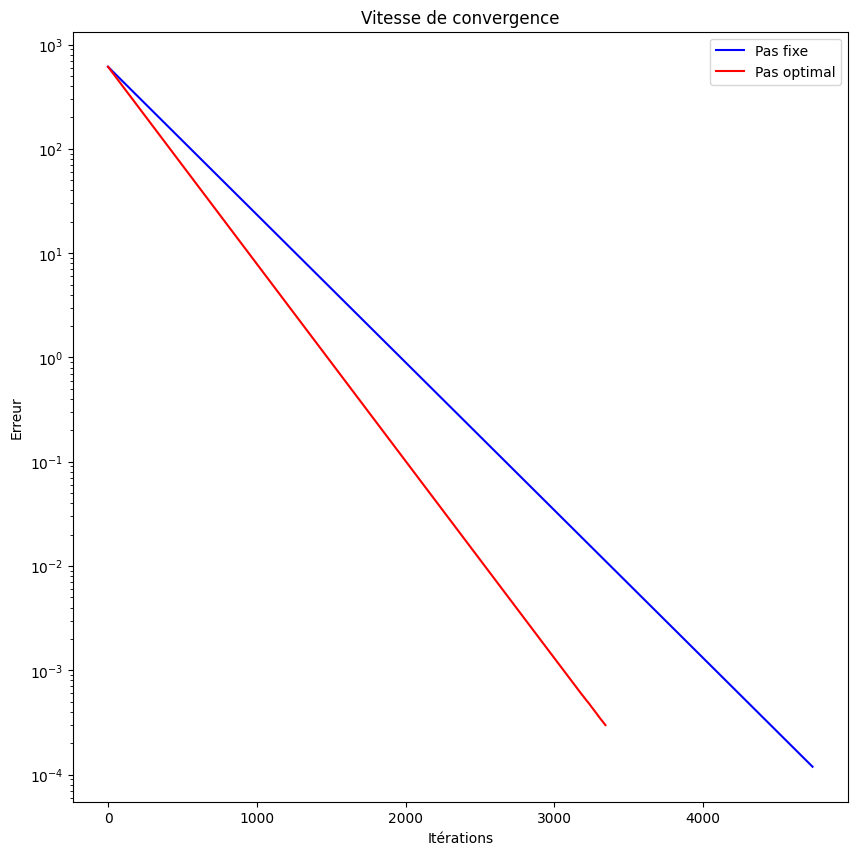

In [116]:
# On affiche la convergence des algorithmes.
plt.figure(figsize=(10, 10))
plt.semilogy(np.linalg.norm(x_PasFixe-sol,axis=1),'-b')
plt.semilogy(np.linalg.norm(x_PasOpt-sol,axis=1),'-r')
plt.legend(['Pas fixe','Pas optimal'])
plt.title('Vitesse de convergence')
plt.xlabel('Itérations')
plt.ylabel('Erreur')
plt.show()

In [117]:
# ILLUSTRATION 2

# Choix des constantes du problème

N = 20
C = 2.0
g = -1.0
d = 500.0

A = matrice_A(N)
b = np.ones(N)

A_gauche = A[1:, 1:]

second_membre = C * np.ones(N - 1) - g * np.asarray(A[1:, 0].todense()).ravel()

sol = np.linalg.solve(A_gauche.toarray(), second_membre)

vp = np.linalg.eigvalsh(A_gauche.toarray())
alpha = np.min(vp)
L = np.max(vp)

pas_fixe = 2 / (alpha + L)

print("Illustration 2")
print("N =", N)
print("C =", C)
print("g =", g)
print("d =", d)
print("alpha =", alpha)
print("L =", L)
print("condition number =", L / alpha)
print("pas_fixe =", pas_fixe)
print("Solution exacte sol =")
print(sol)

# On choisit un point de départ aléatoire pour tester la convergence des algorithmes.
x_init=np.random.randn(N-1)

print('=================================')
print('Algorithme du gradient à pas fixe')
x_PasFixe, f_PasFixe, conv_PasFixe = gradientPasFixe(fct_J_gauche,fct_gradJ_gauche,x_init,pas_fixe,1e-6,5000)
print('Erreur = ',np.linalg.norm(sol-x_PasFixe[-1]))
print('Convergence =',conv_PasFixe)
print('Nombre d itérations = ',np.shape(x_PasFixe)[0]-1)
print('Solution approchée = ',x_PasFixe[-1])

print('=================================')
print('Algorithme du gradient à pas optimal')
x_PasOpt, f_PasOpt, conv_PasOpt = gradientPasOpt(fct_J_gauche,fct_gradJ_gauche,x_init,1e-6,5000)
print('Erreur = ',np.linalg.norm(sol-x_PasOpt[-1]))
print('Convergence =',conv_PasOpt)
print('Nombre d itérations = ',np.shape(x_PasOpt)[0]-1)
print('Solution approchée = ',x_PasOpt[-1])

Illustration 2
N = 20
C = 2.0
g = -1.0
d = 500.0
alpha = 0.006485383731580092
L = 3.9741005252758255
condition number = 612.7780081730923
pas_fixe = 0.5024385971608681
Solution exacte sol =
[ 37.  73. 107. 139. 169. 197. 223. 247. 269. 289. 307. 323. 337. 349.
 359. 367. 373. 377. 379.]
Algorithme du gradient à pas fixe
Erreur =  0.0001460188389258623
Convergence = True
Nombre d itérations =  4884
Solution approchée =  [ 36.99999623  72.99999251 106.9999888  138.99998521 168.99998165
 196.99997829 222.99997498 246.99997193 268.99996896 288.9999663
 306.99996375 322.99996154 336.99995948 348.99995777 358.99995626
 366.9999551  372.99995417 376.99995358 378.99995327]
Algorithme du gradient à pas optimal
Erreur =  0.0006197842974854771
Convergence = True
Nombre d itérations =  3323
Solution approchée =  [ 36.99998407  72.99996808 106.99995261 138.999937   168.99992237
 196.99990756 222.99989413 246.99988053 268.99986861 288.99985661
 306.99984648 322.99983642 336.99982831 348.99982049 358

C:\Users\Acer\AppData\Local\Temp\ipykernel_3536\1063849750.py:18: LineSearchWarning: The line search algorithm did not converge
  pas_opt = optimize.line_search(f,df,x,-df(x))


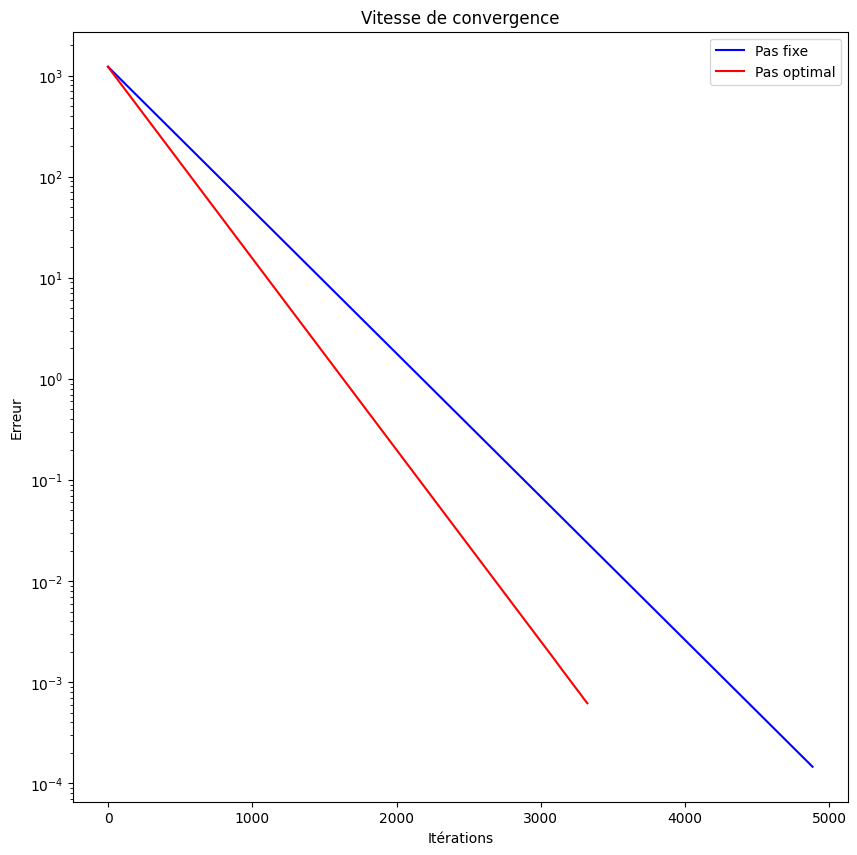

In [118]:
# On affiche la convergence des algorithmes.
plt.figure(figsize=(10, 10))
plt.semilogy(np.linalg.norm(x_PasFixe-sol,axis=1),'-b')
plt.semilogy(np.linalg.norm(x_PasOpt-sol,axis=1),'-r')
plt.legend(['Pas fixe','Pas optimal'])
plt.title('Vitesse de convergence')
plt.xlabel('Itérations')
plt.ylabel('Erreur')
plt.show()

Dans le problème initial, la matrice $A$ est seulement positive semi-définie.
Cependant, après activation forcée de la contrainte gauche $\theta_1=g$,
on optimise sur $u=(\theta_2,\ldots,\theta_N)$. La matrice hessienne du
problème réduit est
$$
A_{\mathrm{gauche}} = A_{2:N,2:N}.
$$
Cette matrice est définie positive. Le problème réduit est donc fortement
convexe, ce qui justifie numériquement la convergence des méthodes de gradient
à pas fixe et à pas optimal.

### 2-2) Vérification

* 12) Vérifier sur un exemple que la solution obtenue numériquement vérifie la contrainte à droite.
* 13) Trouver un exemple sur lequel la solution obtenue numériquement viole la contrainte à droite
* 14) Proposer une amélioration de la méthode dans le cas où la solution viole la contrainte à droite.


**REPONSES** 

* 12)
* 13)
* 14)

In [119]:
# REPONSE 12

# On récupère la solution numérique obtenue par l'algorithme du gradient à pas optimal.
u_num = x_PasOpt[-1]

# On reconstruit le vecteur theta complet :
# theta = (theta_1, theta_2, ..., theta_N)
# avec theta_1 = g et u_num = (theta_2, ..., theta_N)
theta_num = np.concatenate(([g], u_num))

print("Solution numérique complète theta =")
print(theta_num)

print("Valeur à droite theta_N =", theta_num[-1])
print("Contrainte à droite d =", d)

print("La contrainte à droite est vérifiée :", contrainte(theta_num))

Solution numérique complète theta =
[ -1.          36.99998407  72.99996808 106.99995261 138.999937
 168.99992237 196.99990756 222.99989413 246.99988053 268.99986861
 288.99985661 306.99984648 322.99983642 336.99982831 348.99982049
 358.99981457 366.99980922 372.99980562 376.9998029  378.99980169]
Valeur à droite theta_N = 378.9998016905015
Contrainte à droite d = 500.0
La contrainte à droite est vérifiée : True


In [120]:
# REPONSE 13

# On choisit un exemple pour lequel la contrainte droite sera violée.
N = 10
C = 1.0
g = 0.0
d = 20.0

# On reconstruit A et b avec les nouvelles constantes
A = matrice_A(N)
b = np.ones(N)

# Matrice du problème réduit obtenu en fixant theta_1 = g
A_gauche = A[1:, 1:]

# Second membre de l'équation grad J_N^g(u) = 0
second_membre = C * np.ones(N - 1) - g * np.asarray(A[1:, 0].todense()).ravel()

# Solution exacte du problème réduit
sol = np.linalg.solve(A_gauche.toarray(), second_membre)

# Pas fixe optimal théorique
vp = np.linalg.eigvalsh(A_gauche.toarray())
alpha = np.min(vp)
L = np.max(vp)

pas_fixe = 2 / (alpha + L)

# On choisit un point de départ aléatoire
np.random.seed(0)
x_init = np.random.randn(N - 1)

print("Algorithme du gradient à pas optimal")

x_PasOpt, f_PasOpt, conv_PasOpt = gradientPasOpt(
    fct_J_gauche,
    fct_gradJ_gauche,
    x_init,
    1e-6,
    5000
)

print("Convergence =", conv_PasOpt)
print("Nombre d'itérations =", np.shape(x_PasOpt)[0] - 1)
print("Solution approchée u =")
print(x_PasOpt[-1])

# On reconstruit theta = (g, u)
theta_num = np.concatenate(([g], x_PasOpt[-1]))

print("Solution complète theta =")
print(theta_num)

print("theta_N =", theta_num[-1])
print("d =", d)

print("La contrainte à droite est vérifiée :", contrainte(theta_num))

Algorithme du gradient à pas optimal
Convergence = True
Nombre d'itérations = 807
Solution approchée u =
[ 8.99999766 16.99999544 23.99999324 29.99999137 34.99998956 38.99998822
 41.99998703 43.99998633 44.99998592]
Solution complète theta =
[ 0.          8.99999766 16.99999544 23.99999324 29.99999137 34.99998956
 38.99998822 41.99998703 43.99998633 44.99998592]
theta_N = 44.999985919038664
d = 20.0
La contrainte à droite est vérifiée : False


* 14)

Si la solution obtenue en imposant seulement la contrainte gauche
$$
\theta_1=g
$$
viole la contrainte droite
$$
\theta_N\le d,
$$
alors une amélioration naturelle consiste à activer aussi la contrainte droite,
c'est-à-dire à imposer
$$
\theta_1=g,
\qquad
\theta_N=d.
$$

On ne minimise alors plus sur $\mathbb R^{N-1}$, mais sur les variables
intérieures
$$
u=(\theta_2,\ldots,\theta_{N-1})\in\mathbb R^{N-2}.
$$

On reconstruit
$$
\theta=(g,u_1,\ldots,u_{N-2},d).
$$

La fonctionnelle réduite devient
$$
J_N^{g,d}(u)=J_N(g,u,d).
$$

Cette méthode est cohérente avec le problème : si la solution calculée avec
seulement $\theta_1=g$ donne $\theta_N>d$, alors la contrainte droite est
active au minimum admissible. On doit donc résoudre le problème réduit avec les
deux contraintes actives.

In [121]:
# REPONSE 14 — activation des deux contraintes

def fct_J_deux_bords(u):
    """
    Fonctionnelle réduite avec les deux contraintes actives :
        theta_1 = g  et  theta_N = d.

    On note :
        u = (theta_2, ..., theta_{N-1}) in R^{N-2}

    et on reconstruit :
        theta = (g, u_2, ..., u_{N-1}, d) in R^N.

    Alors :
        J_N^{g,d}(u) = J_N(theta).
    """
    u = np.asarray(u, dtype=float)
    if u.shape != (N - 2,):
        raise ValueError(f"u doit être un vecteur de taille {N-2}")
    theta = np.concatenate(([g], u, [d]))
    return fct_J(theta)


def fct_gradJ_deux_bords(u):
    """
    Gradient de J_N^{g,d} par rapport à u = (theta_2, ..., theta_{N-1}).
    C'est le gradient de J_N évalué en theta = (g, u, d),
    privé de sa première et de sa dernière composante.
    """
    u = np.asarray(u, dtype=float)
    if u.shape != (N - 2,):
        raise ValueError(f"u doit être un vecteur de taille {N-2}")
    theta = np.concatenate(([g], u, [d]))
    return fct_gradJ(theta)[1:N-1]


### 3) Algorithmes de descente avec contraintes

Dans cette partie, on va mettre en place une procédure pour utiliser un algorithme de descente avec contraintes, même si les hypothèses du cours ne sont pas vérifiées.
Partons de l'algorithme d'Uzawa.

* 15) Ecrire le lagrangien $\mathcal{L}(\theta,\mu)$ du problème en utilisant les variables $\mu_g$ pour la contrainte de gauche et $\mu_d$ pour la contrainte de droite telles que $\mu = (\mu_g,\mu_d)\in\mathbb{R}_+^2$.
Remarquer que le lagrangien est une fonctionnelle de la forme étudiée précédemment.

* 15)

On écrit les deux contraintes sous la forme
$$
F_g(\theta)=\theta_1-g\le 0,
\qquad
F_d(\theta)=\theta_N-d\le 0.
$$

On introduit deux multiplicateurs de Lagrange positifs
$$
\mu_g\ge 0,
\qquad
\mu_d\ge 0.
$$

En posant
$$
\mu=(\mu_g,\mu_d),
\qquad
F(\theta)=
\begin{pmatrix}
\theta_1-g\\
\theta_N-d
\end{pmatrix},
$$
les contraintes s'écrivent simplement
$$
F(\theta)\le 0.
$$

Le lagrangien associé au problème est
$$
\mathcal L(\theta,\mu)
=
J_N(\theta)+\mu\cdot F(\theta).
$$

C'est-à-dire
$$
\mathcal L(\theta,\mu)
=
J_N(\theta)
+
\mu_g(\theta_1-g)
+
\mu_d(\theta_N-d).
$$

Comme
$$
J_N(\theta)
=
\frac12\langle A\theta,\theta\rangle
-
C\langle \mathbb 1,\theta\rangle,
$$
on obtient
$$
\mathcal L(\theta,\mu)
=
\frac12\langle A\theta,\theta\rangle
-
C\langle \mathbb 1,\theta\rangle
+
\mu_g(\theta_1-g)
+
\mu_d(\theta_N-d).
$$

Les conditions de Kuhn--Tucker associées sont les suivantes.

D'abord, les contraintes primales :
$$
\theta_1-g\le 0,
\qquad
\theta_N-d\le 0.
$$

Ensuite, la positivité des multiplicateurs :
$$
\mu_g\ge 0,
\qquad
\mu_d\ge 0.
$$

Enfin, la condition de complémentarité :
$$
\mu\cdot F(\theta)=0.
$$

C'est-à-dire
$$
\mu_g(\theta_1-g)+\mu_d(\theta_N-d)=0.
$$

Comme chaque terme est le produit d'un multiplicateur positif par une
contrainte négative ou nulle, cette condition équivaut à
$$
\mu_g(\theta_1-g)=0,
\qquad
\mu_d(\theta_N-d)=0.
$$

Ainsi, si une contrainte est inactive, alors son multiplicateur est nul :
$$
\theta_1<g \Rightarrow \mu_g=0,
\qquad
\theta_N<d \Rightarrow \mu_d=0.
$$

Inversement, si un multiplicateur est strictement positif, alors la contrainte
correspondante est active :
$$
\mu_g>0 \Rightarrow \theta_1=g,
\qquad
\mu_d>0 \Rightarrow \theta_N=d.
$$

La condition de stationnarité par rapport à $\theta$ est
$$
\nabla_\theta \mathcal L(\theta,\mu)=0.
$$

Or
$$
\nabla J_N(\theta)=A\theta-C\mathbb 1.
$$

Donc
$$
\nabla_\theta \mathcal L(\theta,\mu)
=
A\theta-C\mathbb 1+\mu_g e_1+\mu_d e_N,
$$
où
$$
e_1=(1,0,\ldots,0),
\qquad
e_N=(0,\ldots,0,1).
$$

La condition de stationnarité est donc
$$
A\theta-C\mathbb 1+\mu_g e_1+\mu_d e_N=0.
$$

Finalement, les conditions de Kuhn--Tucker sont
$$
\boxed{
\begin{cases}
A\theta-C\mathbb 1+\mu_g e_1+\mu_d e_N=0,\\
\theta_1-g\le 0,\quad \theta_N-d\le 0,\\
\mu_g\ge 0,\quad \mu_d\ge 0,\\
\mu_g(\theta_1-g)=0,\quad \mu_d(\theta_N-d)=0.
\end{cases}
}
$$

* 16) Implémenter le lagrangien sous la forme d'une fonction python ``fct_J_Lagrangien`` ainsi que son gradient sous la forme d'une fonction python ``fct_gradJ_Lagrangien``. On fixera les multiplicateurs de Lagrange et les contraintes à des valeurs arbitraires. Elles seront modifiées plus tard.

In [122]:
# REPONSE 16

# Valeurs arbitraires initiales des multiplicateurs de Lagrange.
# Elles seront modifiées plus tard dans l'algorithme d'Uzawa.
mu_g = 0.0
mu_d = 0.0

# Valeurs des contraintes.
# On les initialise avec les contraintes du problème.
g_lagrangien = g
d_lagrangien = d


def fct_J_Lagrangien(theta):
    """
    Calcule le lagrangien

        L(theta, mu) = J_N(theta)
                       + mu_g (theta_1 - g)
                       + mu_d (theta_N - d)

    avec les multiplicateurs mu_g et mu_d fixés.
    """

    theta = np.asarray(theta, dtype=float)

    if theta.shape != (N,):
        raise ValueError(f"theta doit être un vecteur de taille {N}")

    return (
        fct_J(theta)
        + mu_g * (theta[0] - g_lagrangien)
        + mu_d * (theta[-1] - d_lagrangien)
    )


def fct_gradJ_Lagrangien(theta):
    """
    Calcule le gradient du lagrangien par rapport à theta.

    Comme

        grad J_N(theta) = A theta - C b,

    on a

        grad_theta L(theta, mu)
        = grad J_N(theta) + mu_g e_1 + mu_d e_N.
    """

    theta = np.asarray(theta, dtype=float)

    if theta.shape != (N,):
        raise ValueError(f"theta doit être un vecteur de taille {N}")

    grad = fct_gradJ(theta).copy()

    # Contribution de mu_g (theta_1 - g)
    grad[0] += mu_g

    # Contribution de mu_d (theta_N - d)
    grad[-1] += mu_d

    return grad

On rappelle l'algorithme d'Uzawa sur le Lagrangien $\mathcal{L}$.

La première des deux étapes d'Uzawa est une étape d'optimisation, et on pourra appliquer un gradient à pas fixe ou à pas optimal pour résoudre cette étape.

La deuxième étape est l'étape de mise-à-jour à pas fixe du multiplicateur de Lagrange, suivie d'une projection.

On répète ces deux étapes pour $k\in \mathbb{N}$ jusqu'à convergence:
\begin{equation}
\left\{
\begin{aligned}
&\lambda^{(0)}\in \mathbb{R}_+^2 \text{ quelconque} \\
&x^{(k)} = \mathrm{arginf}_{x \in \mathbb{R}^N} \mathcal{L}(x,\lambda^{(k)})\\
&\lambda^{(k+1)} = \Pi_{\mathbb{R}_+^2}(\lambda^{(k)} + h (x^{(k)}_1-p,x^{(k)}_N-q))
\end{aligned}
\right.
\end{equation}
où le pas $h$ de la deuxième étape est fixé.

* 17) Implémenter l'algorithme d'Uzawa sur le Lagrangien $\mathcal{L}$, i.e. sur la fonctionnelle ``fct_J_Lagrangien``.

Afin de décomposer l'algorithme d'Uzawa en plusieurs étapes, on va programmer les différentes étapes dans différentes fonctions.

Remarque importante: Pour pouvoir comparer aux algorithmes précédents, on commencera par un vecteur $x_{init} \in \mathbb{R}^{N-1}$ choisi aléatoirement complété par la contrainte $x_1=g$ dans sa première composante pour obtenir un vecteur $x^{(-1)} \in \mathbb{R}^{N}$. On fixera également $\lambda^{(-1)}=(0,0)$, et on fera l'étape deux pour trouver la valeur de $\lambda^{(0)}$ initiale qui permet de démarrer l'algorithme d'Uzawa.

Autre remarque importante: Attention ! La fonctionnelle $J_N$ n'est ni $\alpha$-convexe, ni strictement convexe, ni même minorée dans $\mathbb{R}^N$ donc, dans l'étape 1, il n'y a aucune raison que les algorithmes à pas fixe ou pas optimal convergent. Il n'y a pas de solution pour y remédier. En pratique, si $\lambda^{(-1)}$ et $x^{(-1)}$ sont choisis proches des solutions, et si l'algorithme à pas fixe ne fait pas trop d'itérations, l'algorithme d'Uzawa va converger.
Pour des valeurs bien choisies des multiplicateurs de Lagrange, le lagrangien est convexe et infini à l'infini, donc il existe des cas relativement simples pour lesquels tout fonctionne parfaitement.

In [123]:
# REPONSE 17

def projection_Rplus(p):
    return np.maximum(0, p)


def contraintes_uzawa(x):
    return np.array([x[0] - g, x[-1] - d])


def update_lambda(x, p, pas_uzawa):
    return projection_Rplus(p + pas_uzawa * contraintes_uzawa(x))


def uzawa(f, df, x_init, pas_uzawa, p_init=None, tol=1e-06, maxiter=1000):

    global mu_g, mu_d

    # x_init est dans R^{N-1}.
    # On construit x^(-1) = (g, x_init) dans R^N.
    x = np.concatenate(([g], x_init.copy()))

    # lambda^(-1)
    if p_init is None:
        p_moins_1 = np.zeros(2)
    else:
        p_moins_1 = p_init.copy()

    # Étape 2 initiale : construction de lambda^(0)
    p = update_lambda(x, p_moins_1, pas_uzawa)

    xtab = [x.copy()]
    ptab = [p.copy()]

    # Pas interne pour la descente sur le lagrangien.
    # On prend un pas raisonnable car A est semi-définie positive.
    lambda_max = np.linalg.eigvalsh(A.toarray()).max()
    pas_interne = 1.0 / lambda_max

    # Nombre volontairement limité d'itérations internes
    maxiter_interne = 20

    it = 0
    conv = False

    while it < maxiter:

        x_old = x.copy()
        p_old = p.copy()

        # Étape 1 : minimisation approchée du lagrangien à p fixé
        mu_g = p[0]
        mu_d = p[1]

        x_lag, f_lag, conv_lag = gradientPasFixe(
            f,
            df,
            x,
            pas=pas_interne,
            tol=tol,
            maxiter=maxiter_interne
        )

        x = x_lag[-1]

        # Étape 2 : mise à jour projetée des multiplicateurs
        p = update_lambda(x, p, pas_uzawa)

        xtab.append(x.copy())
        ptab.append(p.copy())

        # Critère d'arrêt : stabilisation des variables + faisabilité
        critere = (
            np.linalg.norm(x - x_old)
            + np.linalg.norm(p - p_old)
            + np.linalg.norm(np.maximum(contraintes_uzawa(x), 0))
        )

        if critere < tol:
            conv = True
            break

        if np.isnan(np.linalg.norm(x)) or np.isnan(np.linalg.norm(p)):
            conv = False
            break

        it += 1

    # On remet les variables globales à zéro après usage
    mu_g = 0.0
    mu_d = 0.0

    return np.array(xtab), np.array(ptab), conv

On applique ici l'algorithme d'Uzawa : à multiplicateurs fixés, on minimise
le lagrangien en $\theta$, puis on met à jour les multiplicateurs par une
montée de gradient projetée sur $\mathbb R_+^2$.

Cependant, dans notre problème, la matrice $A$ est seulement positive
semi-définie. Comme $A\mathbb 1=0$, le lagrangien n'est pas toujours
minoré en $\theta$. En effet, dans la direction constante $\mathbb 1$, on a
$$
\mathcal L(\theta+s\mathbb 1,\mu)
=
\mathcal L(\theta,\mu)
+
s(\mu_g+\mu_d-CN).
$$
Ainsi, la minimisation intérieure en $\theta$ n'est bien posée que si
$$
\mu_g+\mu_d=CN.
$$
Cette remarque explique pourquoi l'algorithme d'Uzawa peut être numériquement
instable ou ne pas converger dans cette formulation directe.

* 18) Comparer et commenter la méthode 1 et la méthode 2.

In [124]:
# REPONSE 18 - Calcul des suites avant affichage

# Même initialisation pour comparer les trois méthodes
np.random.seed(0)
x_init = np.random.randn(N - 1)

# ------------------------------------------------------------
# Calcul de sol, le vrai minimiseur contraint dans R^N
# ------------------------------------------------------------

A_gauche = A[1:, 1:]
rhs_gauche = C * np.ones(N - 1) - g * np.asarray(A[1:, 0].todense()).ravel()

sol_gauche = np.linalg.solve(A_gauche.toarray(), rhs_gauche)

if sol_gauche[-1] <= d:
    # Une seule contrainte active
    sol = np.concatenate(([g], sol_gauche))

    fJ_grad = fct_J_gauche
    fgJ_grad = fct_gradJ_gauche

    vp = np.linalg.eigvalsh(A_gauche.toarray())
    pas_fixe = 2 / (vp.min() + vp.max())

    x_init_grad = x_init

    def to_full(u):
        return np.concatenate(([g], u))

else:
    # Deux contraintes actives
    A_both = A[1:N-1, 1:N-1]

    rhs_both = (
        C * np.ones(N - 2)
        - g * np.asarray(A[1:N-1, 0].todense()).ravel()
        - d * np.asarray(A[1:N-1, -1].todense()).ravel()
    )

    sol_both = np.linalg.solve(A_both.toarray(), rhs_both)
    sol = np.concatenate(([g], sol_both, [d]))

    fJ_grad = fct_J_deux_bords
    fgJ_grad = fct_gradJ_deux_bords

    vp = np.linalg.eigvalsh(A_both.toarray())
    pas_fixe = 2 / (vp.min() + vp.max())

    x_init_grad = x_init[:N-2]

    def to_full(u):
        return np.concatenate(([g], u, [d]))

print("sol =", sol)

# ------------------------------------------------------------
# Gradient à pas fixe
# ------------------------------------------------------------

x_PasFixe_reduit, f_PasFixe, conv_PasFixe = gradientPasFixe(
    fJ_grad,
    fgJ_grad,
    x_init_grad,
    pas=pas_fixe,
    tol=1e-6,
    maxiter=5000
)

# On reconstruit les vecteurs complets dans R^N
x_PasFixe = np.array([to_full(u) for u in x_PasFixe_reduit])

# ------------------------------------------------------------
# Gradient à pas optimal
# ------------------------------------------------------------

x_PasOpt_reduit, f_PasOpt, conv_PasOpt = gradientPasOpt(
    fJ_grad,
    fgJ_grad,
    x_init_grad,
    tol=1e-6,
    maxiter=5000
)

# On reconstruit les vecteurs complets dans R^N
x_PasOpt = np.array([to_full(u) for u in x_PasOpt_reduit])

# ------------------------------------------------------------
# Algorithme d'Uzawa
# ------------------------------------------------------------

mu_g = 0.0
mu_d = 0.0

pas_uzawa = 1e-2

x_Uzawa, p_Uzawa, conv_Uzawa = uzawa(
    fct_J_Lagrangien,
    fct_gradJ_Lagrangien,
    x_init,
    pas_uzawa,
    tol=1e-6,
    maxiter=5000
)

# ------------------------------------------------------------
# Informations numériques
# ------------------------------------------------------------

print("Convergence pas fixe    =", conv_PasFixe)
print("Convergence pas optimal =", conv_PasOpt)
print("Convergence Uzawa       =", conv_Uzawa)

print("Erreur finale pas fixe    =", np.linalg.norm(x_PasFixe[-1] - sol))
print("Nombre d'itérations       =", np.shape(x_PasFixe)[0] - 1)

print("Erreur finale pas optimal =", np.linalg.norm(x_PasOpt[-1] - sol))
print("Nombre d'itérations       =", np.shape(x_PasOpt)[0] - 1)

print("Erreur finale Uzawa       =", np.linalg.norm(x_Uzawa[-1] - sol))
print("Nombre d'itérations       =", np.shape(x_Uzawa)[0] - 1)

sol = [ 0.          6.22222222 11.44444444 15.66666667 18.88888889 21.11111111
 22.33333333 22.55555556 21.77777778 20.        ]
Convergence pas fixe    = True
Convergence pas optimal = True
Convergence Uzawa       = True
Erreur finale pas fixe    = 4.6719701305701304e-06
Nombre d'itérations       = 259
Erreur finale pas optimal = 7.687085481375424e-06
Nombre d'itérations       = 181
Erreur finale Uzawa       = 0.00014553915383931661
Nombre d'itérations       = 2276


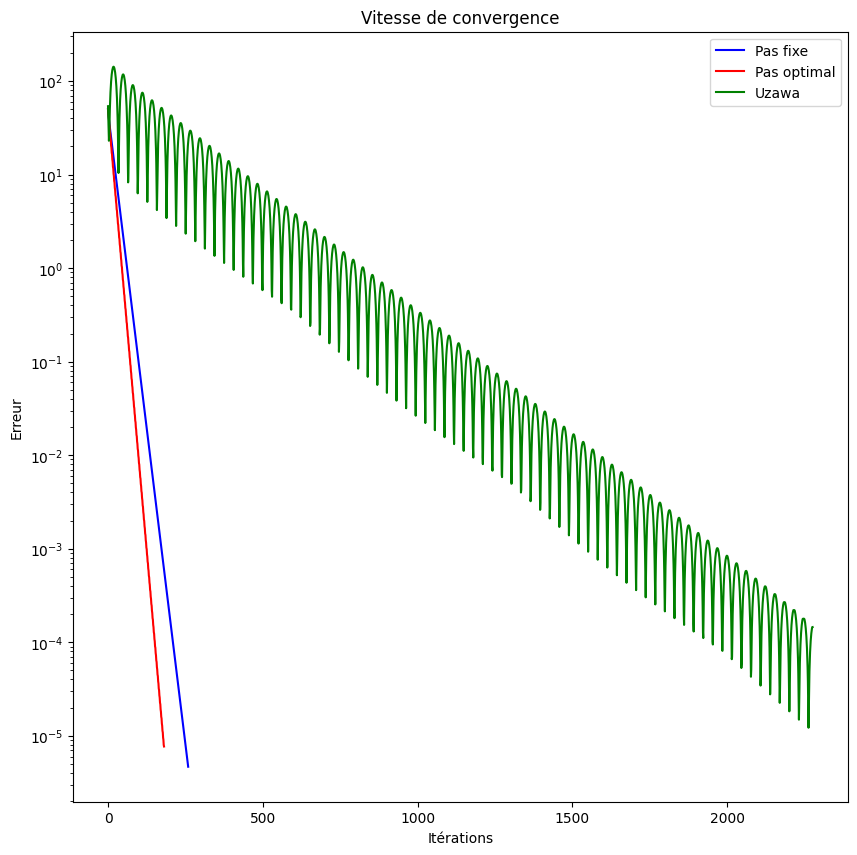

In [125]:
# REPONSE 18
# On affiche la convergence des algorithmes.

plt.figure(figsize=(10, 10))
plt.semilogy(np.linalg.norm(x_PasFixe - sol, axis=1), '-b')
plt.semilogy(np.linalg.norm(x_PasOpt - sol, axis=1), '-r')
plt.semilogy(np.linalg.norm(x_Uzawa - sol, axis=1), '-g')
plt.legend(['Pas fixe', 'Pas optimal', 'Uzawa'])
plt.title('Vitesse de convergence')
plt.xlabel('Itérations')
plt.ylabel('Erreur')
plt.show()

**Méthode 1 (activation des contraintes).**  
Dans cet exemple, la solution obtenue est
$$
\theta^* =
(0,\;6.22,\;11.44,\;15.67,\;18.89,\;21.11,\;22.33,\;22.56,\;21.78,\;20),
$$
ce qui montre que les deux contraintes aux bords sont actives :
$$
\theta_1 = g, \qquad \theta_N = d.
$$
La méthode d'activation des contraintes consiste donc à identifier les contraintes actives, puis à résoudre un problème réduit sur les variables intérieures. Sur ce problème réduit, le Hessien est défini positif : la fonctionnelle devient fortement convexe, ce qui rend les méthodes de gradient bien posées et convergentes.

Numériquement, les deux variantes convergent correctement vers $\theta^*$. Le gradient à pas fixe atteint une erreur finale d'environ $4.67 \times 10^{-6}$ en $259$ itérations, tandis que le gradient à pas optimal atteint une erreur finale d'environ $7.69 \times 10^{-6}$ en $181$ itérations. Le pas optimal est donc plus rapide en nombre d'itérations, car il adapte le pas de descente à chaque étape. La légère différence d'erreur finale n'est pas significative : les deux méthodes s'arrêtent lorsqu'un critère de convergence est satisfait, et non lorsque l'erreur exacte à $\theta^*$ est minimisée.

**Méthode 2 (Uzawa).**  
L'algorithme d'Uzawa converge également dans cet essai, mais beaucoup plus lentement. Il atteint une erreur finale d'environ $1.46 \times 10^{-4}$ après $2276$ itérations. Cette erreur reste raisonnable, mais elle est environ deux ordres de grandeur plus grande que celle obtenue par les méthodes de gradient sur le problème réduit.

Cette différence s'explique par la nature de l'algorithme. La méthode d'Uzawa ne fixe pas a priori les contraintes actives : elle ajuste progressivement les multiplicateurs de Lagrange. Elle est donc plus générale, mais aussi plus lente. De plus, dans notre problème, la matrice $A$ est seulement positive semi-définie, avec
$$
A\mathbf 1 = 0.
$$
Ainsi, pour des multiplicateurs fixés, le lagrangien vérifie
$$
\mathcal L(\theta+s\mathbf 1,\mu)
=
\mathcal L(\theta,\mu)
+
s(\mu_g+\mu_d-CN).
$$
La minimisation intérieure du lagrangien est donc délicate : elle n'est bien contrôlée dans la direction constante que lorsque
$$
\mu_g+\mu_d \approx CN.
$$
C'est pourquoi l'algorithme d'Uzawa demande beaucoup plus d'itérations et dépend davantage du choix du pas, de l'initialisation et du nombre d'itérations internes utilisées pour minimiser le lagrangien.

**Conclusion.**  
La méthode par activation des contraintes est la plus efficace dans cet exemple. Elle exploite directement la structure du problème : une fois les contraintes actives identifiées, on se ramène à un problème fortement convexe, pour lequel les méthodes de gradient sont rapides et robustes. Parmi elles, le pas optimal réduit le nombre d'itérations par rapport au pas fixe.

L'algorithme d'Uzawa est plus général, car il ne nécessite pas d'identifier les contraintes actives à l'avance. Cependant, dans ce problème particulier, il est nettement moins efficace : il converge, mais avec une erreur finale plus grande et un nombre d'itérations beaucoup plus élevé. Cela vient du fait que le lagrangien hérite de la dégénérescence de $A$, ce qui rend la minimisation intérieure moins stable que la résolution du problème réduit.